Columns: ['pair', 'pair_code', 'term', 'coef', 'coef_pct_points', 'std_err', 'std_err_pct_points', 'p_value', 'ci_low_pct_points', 'ci_high_pct_points', 'nobs', 'r_squared', 'weight_var', 'file']
        pair  pair_code      term      coef  coef_pct_points   std_err  \
0  2008-2009        809  illinois  0.001154         0.115402  0.005251   
1  2009-2010        910  illinois  0.008434         0.843377  0.005015   
2  2010-2011       1011  illinois  0.009748         0.974783  0.005061   
3  2011-2012       1112  illinois -0.002283        -0.228300  0.005086   
4  2012-2013       1213  illinois  0.019922         1.992160  0.005332   

   std_err_pct_points   p_value  ci_low_pct_points  ci_high_pct_points  nobs  \
0            0.525094  0.826047          -0.913763            1.144566  6424   
1            0.501514  0.092635          -0.139573            1.826327  6157   
2            0.506125  0.054108          -0.017204            1.966770  6015   
3            0.508644  0.653547        

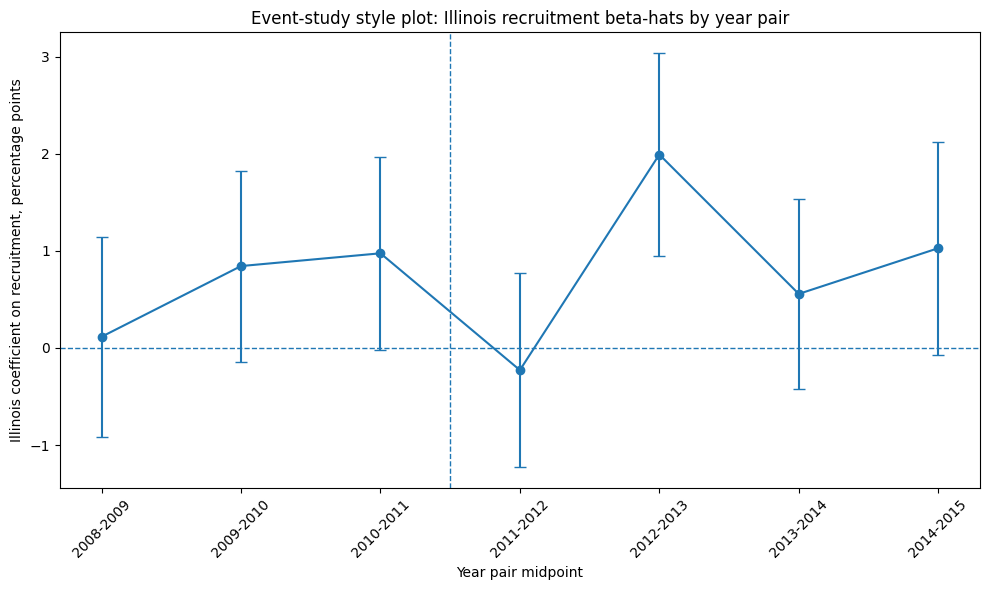

Saved event-study plot: /Users/subhronil/Downloads/second_stage_beta_results/event_study_illinois_beta_hats.png


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import statsmodels.api as sm

INPUT_FILE = Path.home() / "Downloads" / "recruitment_weighted_illinois_effects.csv"

OUTPUT_DIR = Path.home() / "Downloads" / "second_stage_beta_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

POLICY_YEAR = 2011

df = pd.read_csv(INPUT_FILE)
df.columns = df.columns.str.lower().str.strip()

print("Columns:", df.columns.tolist())
print(df.head())

# Rename likely columns
rename_map = {
    "year pair": "pair",
    "year_pair": "pair",
    "std. error": "std_err",
    "standard error": "std_err",
    "p-value": "p_value",
    "r-squared": "r_squared",
    "n": "nobs",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

def parse_pp_or_number(x):
    """
    Converts:
    - '4.2 pp' -> 0.042
    - '4.2%'   -> 0.042
    - 0.042    -> 0.042
    """
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    s = str(x).strip().lower()
    if "pp" in s or "%" in s:
        s = s.replace("pp", "").replace("%", "").strip()
        return float(s) / 100
    return float(s)

# Detect beta and SE columns
if "coef" in df.columns:
    df["beta_hat"] = pd.to_numeric(df["coef"], errors="coerce")
elif "effect" in df.columns:
    df["beta_hat"] = df["effect"].apply(parse_pp_or_number)
elif "coefficient" in df.columns:
    df["beta_hat"] = df["coefficient"].apply(parse_pp_or_number)
else:
    raise ValueError("Could not find beta column. Expected one of: coef, effect, coefficient.")

if "std_err" in df.columns:
    df["se_beta"] = df["std_err"].apply(parse_pp_or_number)
elif "se" in df.columns:
    df["se_beta"] = df["se"].apply(parse_pp_or_number)
else:
    raise ValueError("Could not find standard error column. Expected std_err or se.")

# Extract year pair
if "pair" not in df.columns:
    if "pair_code" in df.columns:
        df["pair"] = df["pair_code"].astype(str)
    else:
        raise ValueError("Could not find pair column.")

# Handles either 2008-2009 or 0809
pair_str = df["pair"].astype(str)

year_extract_4 = pair_str.str.extract(r"(\d{4})\D+(\d{4})")
year_extract_2 = pair_str.str.extract(r"(\d{2})(\d{2})")

df["y0"] = pd.to_numeric(year_extract_4[0], errors="coerce")
df["y1"] = pd.to_numeric(year_extract_4[1], errors="coerce")

missing_years = df["y0"].isna() | df["y1"].isna()
df.loc[missing_years, "y0"] = 2000 + pd.to_numeric(year_extract_2.loc[missing_years, 0], errors="coerce")
df.loc[missing_years, "y1"] = 2000 + pd.to_numeric(year_extract_2.loc[missing_years, 1], errors="coerce")

df["y0"] = df["y0"].astype(int)
df["y1"] = df["y1"].astype(int)

# Post-policy indicator
df["post"] = (df["y0"] >= POLICY_YEAR).astype(int)

# Professor's recommended second-stage weights:
# inverse squared first-stage standard error
df = df.dropna(subset=["beta_hat", "se_beta", "post"])
df = df[df["se_beta"] > 0].copy()
df["second_stage_weight"] = 1 / (df["se_beta"] ** 2)

print("\nSecond-stage input:")
print(df[["pair", "y0", "y1", "beta_hat", "se_beta", "post", "second_stage_weight"]])

# Second-stage regression
X = sm.add_constant(df["post"])
y = df["beta_hat"]
w = df["second_stage_weight"]

model = sm.WLS(y, X, weights=w).fit()

results = pd.DataFrame({
    "term": model.params.index,
    "coef": model.params.values,
    "std_err": model.bse.values,
    "t_stat": model.tvalues.values,
    "p_value": model.pvalues.values,
    "ci_low": model.conf_int()[0].values,
    "ci_high": model.conf_int()[1].values,
})

# Make presentation-readable percentage point columns
for col in ["coef", "std_err", "ci_low", "ci_high"]:
    results[col + "_pp"] = results[col] * 100

readable = results[[
    "term",
    "coef_pp",
    "std_err_pp",
    "p_value",
    "ci_low_pp",
    "ci_high_pp"
]].rename(columns={
    "coef_pp": "Coefficient (pp)",
    "std_err_pp": "Std. error (pp)",
    "p_value": "p-value",
    "ci_low_pp": "95% CI low (pp)",
    "ci_high_pp": "95% CI high (pp)",
})

readable["Interpretation"] = readable["term"].map({
    "const": "Average Illinois recruitment beta-hat before 2011",
    "post": "Average post-2011 shift in Illinois recruitment beta-hat",
})

for col in ["Coefficient (pp)", "Std. error (pp)", "95% CI low (pp)", "95% CI high (pp)"]:
    readable[col] = readable[col].round(3)

readable["p-value"] = readable["p-value"].round(4)

# Save
input_out = OUTPUT_DIR / "second_stage_input_betas.csv"
results_out = OUTPUT_DIR / "second_stage_results.csv"
excel_out = OUTPUT_DIR / "second_stage_beta_regression.xlsx"

df.to_csv(input_out, index=False)
readable.to_csv(results_out, index=False)

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="input_betas", index=False)
    readable.to_excel(writer, sheet_name="second_stage_results", index=False)

print("\n" + "=" * 80)
print("SECOND-STAGE REGRESSION RESULTS")
print("=" * 80)
print(readable.to_string(index=False))

print("\nSaved:")
print(input_out)
print(results_out)
print(excel_out)

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Event-study style plot: Illinois beta-hats over time
# ------------------------------------------------------------

plot_df = df.copy()
plot_df["mid_year"] = (plot_df["y0"] + plot_df["y1"]) / 2
plot_df["beta_pp"] = plot_df["beta_hat"] * 100
plot_df["se_pp"] = plot_df["se_beta"] * 100
plot_df["ci_low_pp"] = plot_df["beta_pp"] - 1.96 * plot_df["se_pp"]
plot_df["ci_high_pp"] = plot_df["beta_pp"] + 1.96 * plot_df["se_pp"]

plt.figure(figsize=(10, 6))

plt.errorbar(
    plot_df["mid_year"],
    plot_df["beta_pp"],
    yerr=1.96 * plot_df["se_pp"],
    fmt="o-",
    capsize=4
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(POLICY_YEAR, linestyle="--", linewidth=1)

plt.title("Event-study style plot: Illinois recruitment beta-hats by year pair")
plt.xlabel("Year pair midpoint")
plt.ylabel("Illinois coefficient on recruitment, percentage points")
plt.xticks(plot_df["mid_year"], plot_df["pair"], rotation=45)
plt.tight_layout()

event_plot_out = OUTPUT_DIR / "event_study_illinois_beta_hats.png"
plt.savefig(event_plot_out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved event-study plot:", event_plot_out)